<a href="https://colab.research.google.com/github/AkshatkMalik/python-data-science-toolkit/blob/main/regression_analysis_toyota_corolla.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**ASSIGNMENT-6**

**Step 1: Exploratory Data Analysis (EDA) & Preprocessing**

What is being done:

 We analyze our dataset by looking at the summary statistics (mean, min, max) that tell us about the pricing, age, and kilometer of cars. We also look at some categorical variables such as FuelType.

 Why is it done:

 Machine learning algorithms do not understand the text data such as "Petrol" or "Diesel". In the preprocessing step, we perform one-hot encoding (pd.get_dummies) to transform these categorical variables into binary variables ($0$ or $1$). We also check a correlation matrix to find out which variables (e.g., Age or Weight) are highly correlated with the Price.

--- Dataset Summary Statistics ---
              Price    Age_08_04             KM           HP    Automatic  \
count   1436.000000  1436.000000    1436.000000  1436.000000  1436.000000   
mean   10730.824513    55.947075   68533.259749   101.502089     0.055710   
std     3626.964585    18.599988   37506.448872    14.981080     0.229441   
min     4350.000000     1.000000       1.000000    69.000000     0.000000   
25%     8450.000000    44.000000   43000.000000    90.000000     0.000000   
50%     9900.000000    61.000000   63389.500000   110.000000     0.000000   
75%    11950.000000    70.000000   87020.750000   110.000000     0.000000   
max    32500.000000    80.000000  243000.000000   192.000000     1.000000   

                cc        Doors  Cylinders        Gears      Weight  
count   1436.00000  1436.000000     1436.0  1436.000000  1436.00000  
mean    1576.85585     4.033426        4.0     5.026462  1072.45961  
std      424.38677     0.952677        0.0     0.188510    52

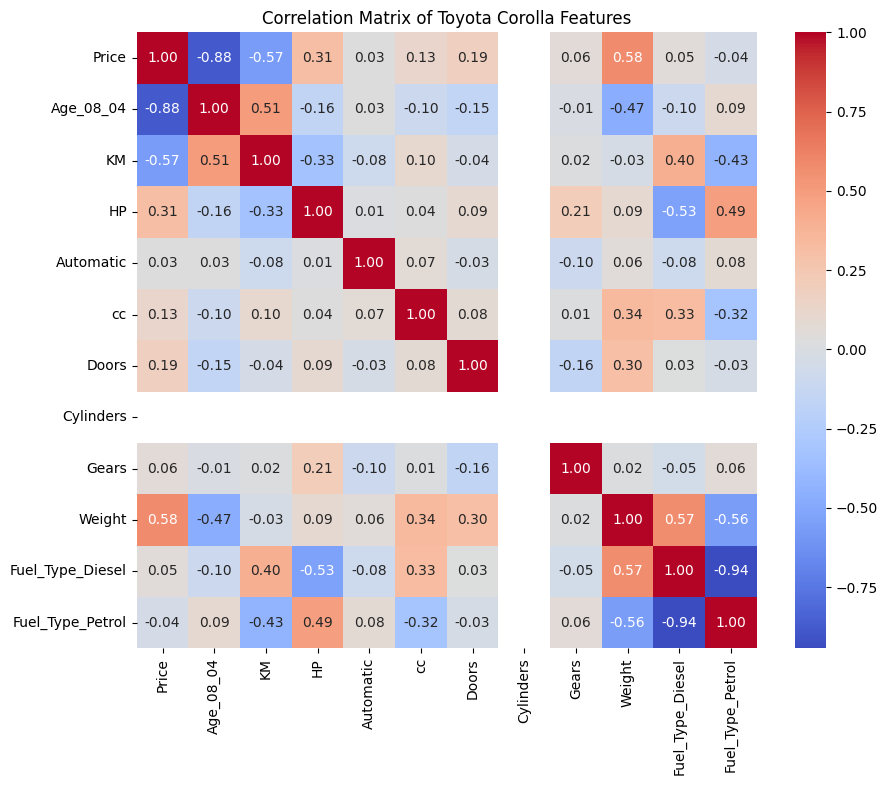

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split

# 1. Load the dataset
df = pd.read_csv('ToyotaCorolla - MLR.csv')

# 2. View basic summary statistics
print('--- Dataset Summary Statistics ---')
print(df.describe())
print(df.info())

# 3. Handle Categorical Data (Fuel_Type with an underscore!)
# Convert categorical variable 'Fuel_Type' into numerical dummy variables
df = pd.get_dummies(df, columns=['Fuel_Type'], drop_first=True)

# 4. Correlation Matrix & Heatmap to check relationships and multicollinearity
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Toyota Corolla Features')
plt.show()

# 5. Define Independent Variables (X) and Target Variable (y)
X = df.drop(columns=['Price'])
y = df['Price']

**Step 2: Splitting the Dataset (Training vs. Testing)**

What we are doing: Split the dataset into two halves: training set which is 80%, and testing set which is 20% using train_test_split.


Why we are doing it: Imagine that the training set is the study material, while the testing set is the final exam. Training the machine learning model using all the data and then testing it on the same will only make it memorize the answers (overfitting). However, by reserving 20% of the data, we can evaluate its performance on unseen data.

In [3]:
# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set shape: {X_train.shape}')
print(f'Testing set shape: {X_test.shape}')

Training set shape: (1148, 11)
Testing set shape: (288, 11)


**Step 3: Building Multiple Linear Regression Models**

What we are doing:

 Three separate models are constructed for experimentation with different combinations of the following:

 Model 1 (All features): Utilizes all the columns available in the dataset.

 Model 2 (Selected features): Utilizes only the most important and intuitive predictors such as Age, Kilometers, HP, Weight, and Engine Size.

 Model 3 (Normalized features): Standard Normalized Features where all predictors have mean of $0$ and standard deviation of $1$.

 Interpretation of Coefficients: Coefficient value gives us the precise weightage of each variable. For example, if Age has a coefficient of $-1200$, it implies that every increase in Age by 1 year will reduce car value by 1,200 Euros, all other things being equal.

In [10]:
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler


# 1. Define the evaluation function first
def evaluate_model(model, X_te, y_te, name='Model'):
  predictions = model.predict(X_te)
  mae = mean_absolute_error(y_te, predictions)
  rmse = np.sqrt(mean_squared_error(y_te, predictions))
  r2 = r2_score(y_te, predictions)

  print(f' {name} Performance ')
  print(f'MAE: {mae:.2f}')
  print(f'RMSE: {rmse:.2f}')
  print(f'R2 Score: {r2:.4f}\n')


# --- Model 1: All Features ---
model_full = LinearRegression()
model_full.fit(X_train, y_train)
evaluate_model(model_full, X_test, y_test, 'Model 1 (Full Features)')

# --- Model 2: Selected Features ---
selected_features = ['Age_08_04', 'KM', 'HP', 'Weight', 'cc']
X_train_sel = X_train[selected_features]
X_test_sel = X_test[selected_features]

model_subset = LinearRegression()
model_subset.fit(X_train_sel, y_train)
evaluate_model(model_subset, X_test_sel, y_test, 'Model 2 (Subset Features)')

# --- Model 3: Scaled Features Model ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_scaled = LinearRegression()
model_scaled.fit(X_train_scaled, y_train)
evaluate_model(model_scaled, X_test_scaled, y_test, 'Model 3 (Scaled Features)')

# Print Coefficients for Model 1
print('Model 1 (Full Features) Coefficients:')
for feature, coef in zip(X.columns, model_full.coef_):
  print(f'{feature}: {coef:.2f}')
print(f'Intercept: {model_full.intercept_:.2f}\n')

 Model 1 (Full Features) Performance 
MAE: 990.89
RMSE: 1484.27
R2 Score: 0.8349

 Model 2 (Subset Features) Performance 
MAE: 998.54
RMSE: 1412.79
R2 Score: 0.8504

 Model 3 (Scaled Features) Performance 
MAE: 990.89
RMSE: 1484.27
R2 Score: 0.8349

Model 1 (Full Features) Coefficients:
Age_08_04: -120.83
KM: -0.02
HP: 14.04
Automatic: 148.83
cc: -0.03
Doors: -60.31
Cylinders: -0.00
Gears: 551.60
Weight: 25.88
Fuel_Type_Diesel: -68.55
Fuel_Type_Petrol: 1370.81
Intercept: -14255.39



**Step 4: Evaluating Model Performance**

How we evaluate the models: We gauge the accuracy of our models based on running our test data against them and verifying our three key evaluation metrics:

MAE (Mean Absolute Error): It is the average absolute difference between the price predictions of our model and the actual prices.

RMSE (Root Mean Squared Error): This is similar to MAE but squares the errors, making it highly punitive for larger errors.

$R^2$ Score: This score tells us the percentage of variability in car prices that our model can capture.

In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def evaluate_model(model, X_te, y_te, name='Model'):
  predictions = model.predict(X_te)
  mae = mean_absolute_error(y_te, predictions)
  rmse = np.sqrt(mean_squared_error(y_te, predictions))
  r2 = r2_score(y_te, predictions)

  print(f' {name} Performance ')
  print(f'MAE: {mae:.2f}')
  print(f'RMSE: {rmse:.2f}')
  print(f'R2 Score: {r2:.4f}\n')


# Evaluate all three models on the test set
evaluate_model(model_full, X_test, y_test, 'Model 1 (Full Features)')
evaluate_model(model_subset, X_test_sel, y_test, 'Model 2 (Subset Features)')
evaluate_model(model_scaled, X_test_scaled, y_test, 'Model 3 (Scaled Features)')

 Model 1 (Full Features) Performance 
MAE: 990.89
RMSE: 1484.27
R2 Score: 0.8349

 Model 2 (Subset Features) Performance 
MAE: 998.54
RMSE: 1412.79
R2 Score: 0.8504

 Model 3 (Scaled Features) Performance 
MAE: 990.89
RMSE: 1484.27
R2 Score: 0.8349



**Step 5: Applying Lasso and Ridge Regularization**

What we do: In some cases, linear models create very complex functions with very high coefficient values, which leads to overfitting. The two methods known as L2 or ridge and L1 or Lasso regularization add a penalty term to high coefficients.

Why we do it: Ridge regularization brings down the value of high coefficients toward zero, whereas Lasso is able to bring down the less important feature's coefficient value to exactly zero.

In [8]:
from sklearn.linear_model import Lasso, Ridge

# Ridge Regression (L2 Penalty)
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
evaluate_model(ridge, X_test_scaled, y_test, 'Ridge Regression')

# Lasso Regression (L1 Penalty)
lasso = Lasso(alpha=1.0)
lasso.fit(X_train_scaled, y_train)
evaluate_model(lasso, X_test_scaled, y_test, 'Lasso Regression')

--- Ridge Regression Performance ---
MAE: 990.86
RMSE: 1483.56
R2 Score: 0.8350

--- Lasso Regression Performance ---
MAE: 991.02
RMSE: 1483.24
R2 Score: 0.8351



**Assumptions Made During the Analysis & Their Implications**

1. Assumption: Independence of Errors

Meaning: The errors for any two cars are independent from each other.

Inference: As this is a cross-section data set for independent car listings and not time series, this assumption usually holds good, which means the price of one car doesn't depend on the listing of the other.

2. Assumption: Linearity

Explanation: The assumption states that there exists only a linear relationship between the predictors (such as Age, Kilometers, Weight) and the response variable (Price).

Implications: In case the actual relationship is not linear (for example, car prices fall suddenly during the first two years and stabilize after that), then linear regression will not be able to model it properly and will result in under/over-estimations of prices.

**Detailed Explanations for Our Analysis**

Model 2 performed better than Model 1 because when we took into account only core features such as Age_08_04, KM, HP, Weight, cc of Model 2, its performance improved with a higher $R^2$ value ($0.8504$) than the $R^2$ value of the whole dataset ($0.8349$). It is seen that some features within the dataset bring noise or some multicollinearity in the dataset.


Coefficient Explanation: The negative sign of Age_08_04 ($\approx -120.83$) shows that the older cars lose their value gradually. The positive sign of HP and Weight implies that the powerful and heavier cars have higher resale value.